**Tonny Talukder
ID : 0432220005101050**

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

In [3]:
##1. Data Preparation

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# a. Load dataset + b. Standardize
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

dataset = datasets.MNIST(root='./data', train=True, transform=transform, download=True)

# c. Train-Test Split (80-20)
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size

train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=1000, shuffle=False)

print("Train size:", len(train_dataset))
print("Test size:", len(test_dataset))

100%|██████████| 9.91M/9.91M [00:00<00:00, 39.6MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.06MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 9.95MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 10.1MB/s]

Train size: 48000
Test size: 12000


In [4]:
##2. Single Perceptron
# Single Layer Perceptron

class Perceptron(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc = nn.Linear(784, 10)

    def forward(self, x):
        return self.fc(x)

model_sp = Perceptron().to(device)
optimizer = optim.Adam(model_sp.parameters(), lr=1e-3)

def train(model, loader):
    model.train()
    for epoch in range(5):
        for X, y in loader:
            X, y = X.to(device), y.to(device)
            X = X.view(X.size(0), -1)

            optimizer.zero_grad()
            out = model(X)
            loss = F.cross_entropy(out, y)
            loss.backward()
            optimizer.step()

def accuracy(model, loader):
    model.eval()
    correct = 0
    with torch.no_grad():
        for X, y in loader:
            X, y = X.to(device), y.to(device)
            X = X.view(X.size(0), -1)
            pred = model(X).argmax(1)
            correct += (pred == y).sum().item()
    return 100 * correct / len(loader.dataset)

# Train
train(model_sp, train_loader)

train_acc = accuracy(model_sp, train_loader)
test_acc  = accuracy(model_sp, test_loader)

print("Single Perceptron Train Acc:", train_acc)
print("Single Perceptron Test Acc:", test_acc)

Single Perceptron Train Acc: 91.625
Single Perceptron Test Acc: 90.7


MLP Test Accuracy: 93.1


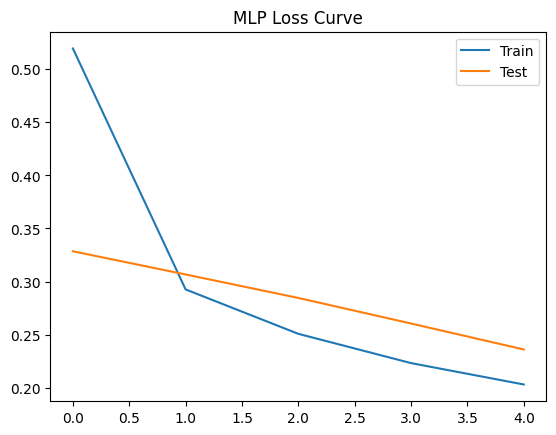

In [5]:
##3. Multi-Layer perceptron (MLP)

class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(784, 32)
        self.fc2 = nn.Linear(32, 10)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        return self.fc2(x)

model_mlp = MLP().to(device)
optimizer = optim.Adam(model_mlp.parameters(), lr=1e-3)

train_losses = []
test_losses = []

for epoch in range(5):
    model_mlp.train()
    running_loss = 0

    for X, y in train_loader:
        X, y = X.to(device), y.to(device)
        X = X.view(X.size(0), -1)

        optimizer.zero_grad()
        out = model_mlp(X)
        loss = F.cross_entropy(out, y)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    train_losses.append(running_loss/len(train_loader))

    # validation loss
    model_mlp.eval()
    loss_val = 0
    with torch.no_grad():
        for X, y in test_loader:
            X, y = X.to(device), y.to(device)
            X = X.view(X.size(0), -1)
            out = model_mlp(X)
            loss_val += F.cross_entropy(out, y).item()

    test_losses.append(loss_val/len(test_loader))

# Accuracy
mlp_test_acc = accuracy(model_mlp, test_loader)
print("MLP Test Accuracy:", mlp_test_acc)

# Loss Curve
plt.plot(train_losses, label='Train')
plt.plot(test_losses, label='Test')
plt.legend()
plt.title("MLP Loss Curve")
plt.show()

In [6]:
##4. Deep Neural Network ( DNN )

class DNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(784, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 32)
        self.fc4 = nn.Linear(32, 10)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = F.relu(self.fc3(x))
        return self.fc4(x)

model_dnn = DNN().to(device)
optimizer = optim.Adam(model_dnn.parameters(), lr=1e-3)

train(model_dnn, train_loader)

dnn_test_acc = accuracy(model_dnn, test_loader)

print("DNN Test Accuracy:", dnn_test_acc)

DNN Test Accuracy: 96.01666666666667


In [7]:
##5. ID-Based Model Variatyion
##ID = 0432220005101050
##Last 2 digit = 50
##Hidden neurons = (50 % 50) + 10 = 10

class MLP_ID(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(784, 10)
        self.fc2 = nn.Linear(10, 10)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        return self.fc2(x)

model_id = MLP_ID().to(device)
optimizer = optim.Adam(model_id.parameters(), lr=1e-3)

train(model_id, train_loader)

id_acc = accuracy(model_id, test_loader)

print("ID-based MLP Accuracy:", id_acc)




ID-based MLP Accuracy: 86.8


In [8]:
##6. Overfitting Analysis
##MLP (32 neuron) > ID-based (10 neuron)
##Reason: less neurons → less learning capacity

train_acc = accuracy(model_dnn, train_loader)
test_acc  = accuracy(model_dnn, test_loader)

print("Train:", train_acc)
print("Test:", test_acc)


Train: 97.25
Test: 96.01666666666667
